SET UP AND DATA LOADING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")  #Set background style for seaborn plots
plt.rcParams['figure.figsize'] =(10, 6)   #Set default size(width, height in inches

diabetes = pd.read_csv("diabetes.csv")

In [2]:
#Show the first top/bottom 5 row/column of the dataset
diabetes.head

<bound method NDFrame.head of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50 

In [3]:
# Dataset Description

print(diabetes.info())
print(diabetes.shape)
print(diabetes.describe())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
(768, 9)
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std      

DATA QUALITY CHECK

In [4]:
# Missing values check
print(diabetes.isnull().sum())

#Duplicates
print(f"Duplicates: {diabetes.duplicated().sum()}")

#Zero value check for some features(Glucuse,BloodPressure,SkinThickness,Insulin,BMI)
#Zero value means missing data; 0 not a physiological value for these columns

zero_check_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_check_cols:
    print(f"{col}: {(diabetes[col] == 0).sum()} zero values ({(diabetes[col]==0).mean()*100:.1f}%)")


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Duplicates: 0
Glucose: 5 zero values (0.7%)
BloodPressure: 35 zero values (4.6%)
SkinThickness: 227 zero values (29.6%)
Insulin: 374 zero values (48.7%)
BMI: 11 zero values (1.4%)


Insulin and SkinThickness cotain a substantial portion of zero values(48.7% and 29.6% respectively), which are not physiologically plausible and likely represent missing data rather than true measurements. Findings involving these two features should be interpreted with caution.

In [5]:
# Zero values conversion to NaN
zero_check_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
diabetes[zero_check_cols] = diabetes[zero_check_cols].replace(0, np.nan)

#Confirmation
print(diabetes.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


TARGET DISTRIBUTION

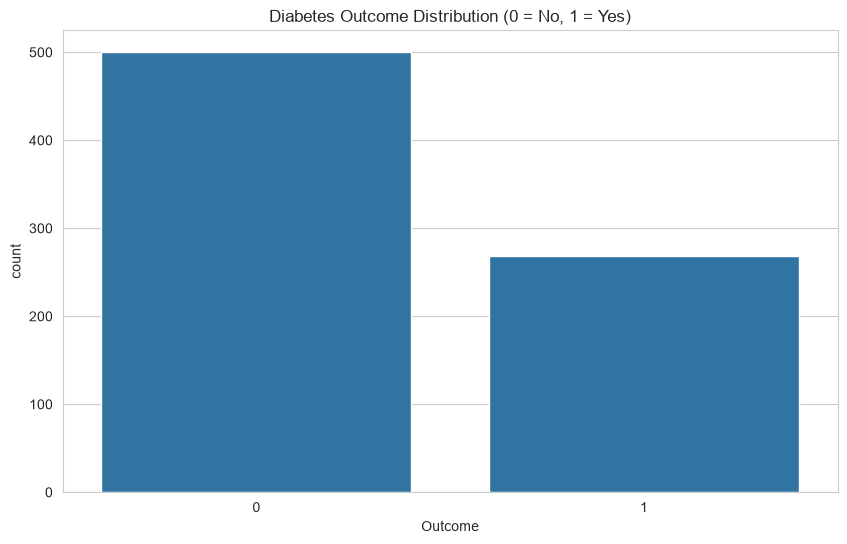

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [6]:
# Countplot for target variable
diabetes['Outcome'].value_counts()

plt.figure(figsize=(10, 6))
sns.countplot(x='Outcome', data=diabetes)
plt.title('Diabetes Outcome Distribution (0 = No, 1 = Yes)')
plt.savefig('images/outcome_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(diabetes['Outcome'].value_counts(normalize=True) * 100)

The dataset shows class imbalance, with 65.1% non-diabetic(Outcome=0) and 34.9% diabetic(Outcome=1)cases. This should be considered when inerpreting patterns in the data, and would be an important factore in the future modeling work(i.e accuracy alone would be misleading: technique like class weighing or resampling would be needed).

UNIVARIATE ANALYSIS

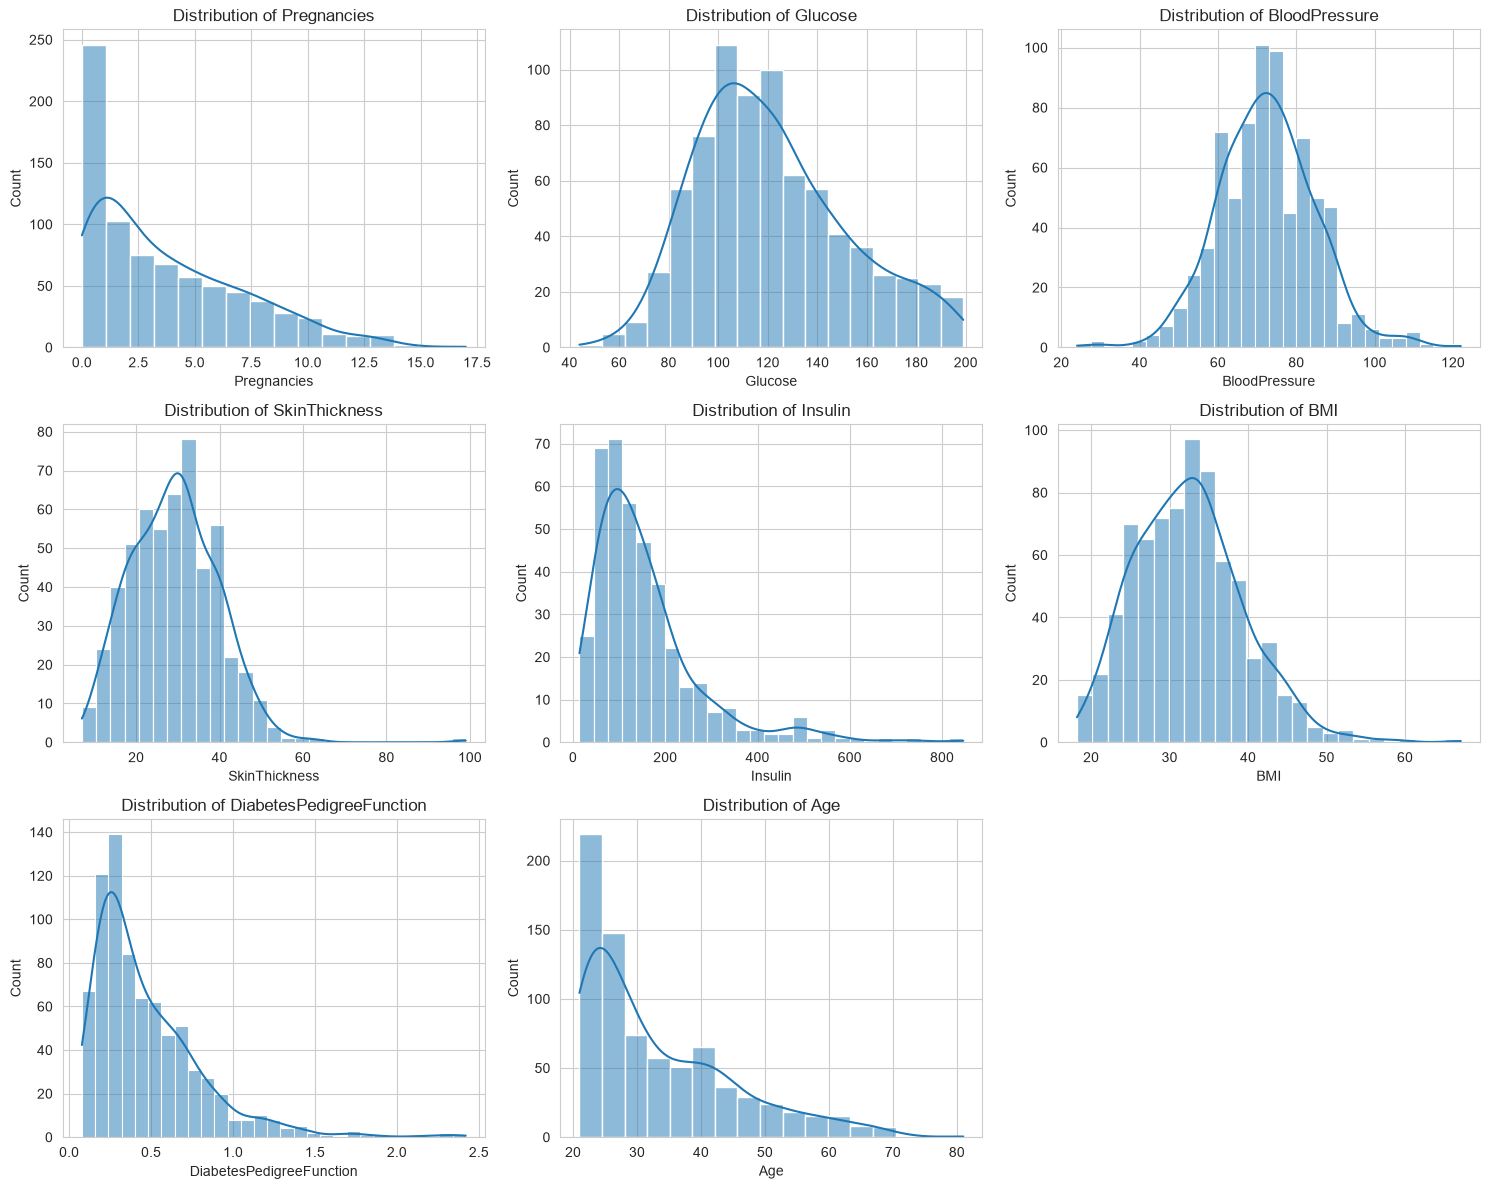

In [7]:
# Distribution of all the features (Histplot)

numeric_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
                'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(diabetes[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
axes[-1].axis('off')   #Unused 9th subplot
plt.tight_layout()
plt.savefig('images/feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

Glucose, BloodPressure, and BMI show approximately normal distributions. Pregnancies, SkinThickness, Insulin, DiabetesPedigreeFunction, and Age are right-skewed, meaning most values cluster at the lower end with a log tail towards higher values. This is expected given the nature of these variables-for example, most patient in the sample are younger adults with few pregnancies, while a smaller number have much higher values.

FEATURES VS OUTCOME

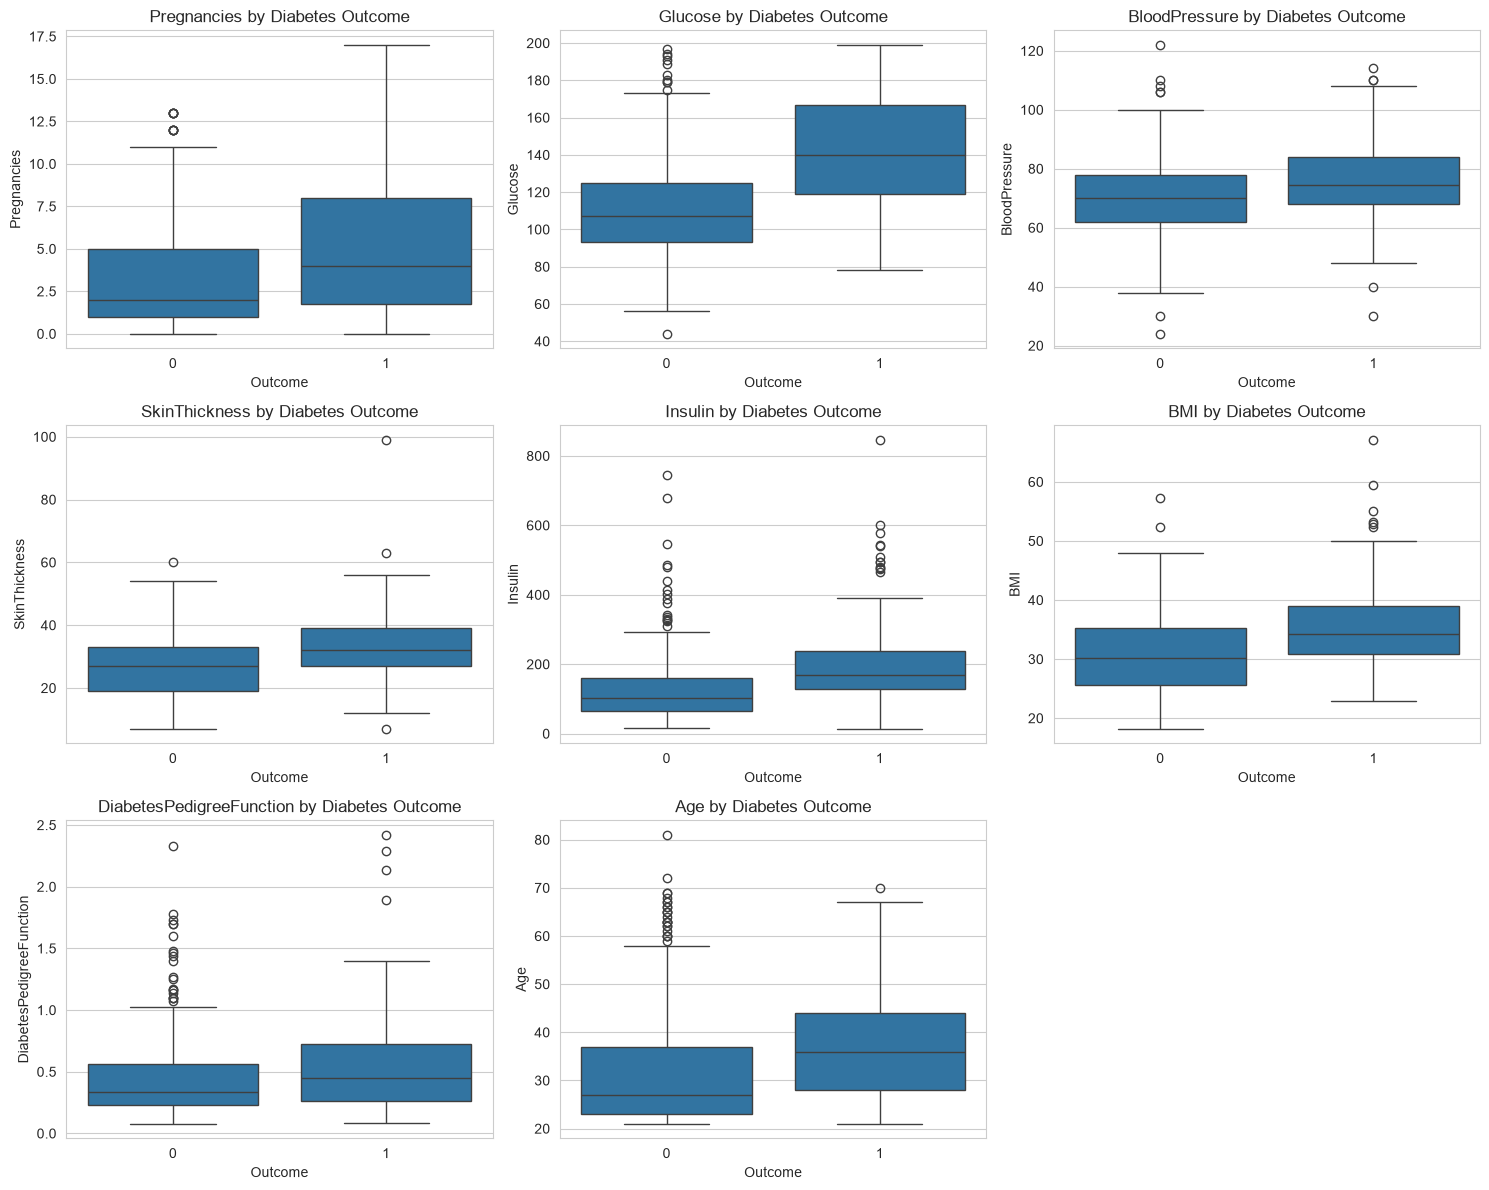

In [8]:
#Boxplot of features vs Outcome
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Outcome', y=col, data=diabetes, ax=axes[i])
    axes[i].set_title(f'{col} by Diabetes Outcome')
axes[-1].axis('off')   #Unused 9th subplot
plt.tight_layout()
plt.savefig('images/feature_by_outcome.png', dpi=300, bbox_inches='tight')
plt.show()

Glucose shows the clearest seperation between diabetic and non diabetic groups, with the diabetic group's median glucose level roughly 30-35 points higher. age, BMI, and Pregnancies also show moderate seperation, with diabetic patients tending to be older, have higher BMI, and more prior pregnancies. BloodPressureFunction show the least visual seperation between groups, suggesting they may be weaker standalone predictors of diabetes risk in this dataset.

C0RRELATION HEATMAP

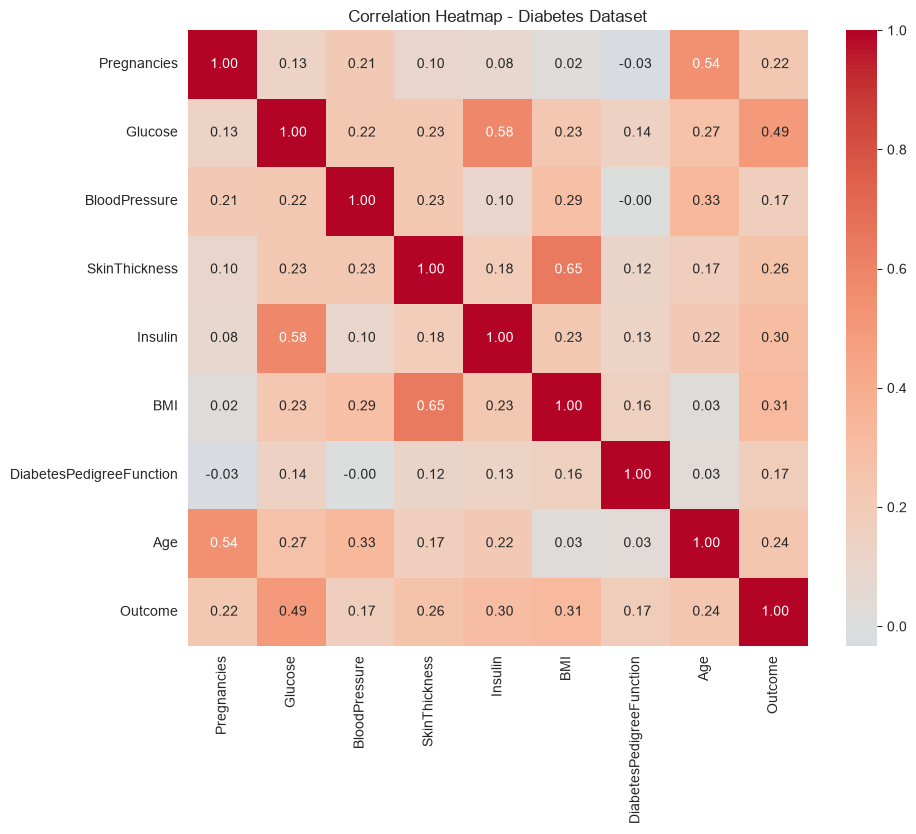

Outcome                     1.000000
Glucose                     0.494650
BMI                         0.313680
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64


In [11]:
# Correlation with Outcome: Linear relationships

plt.figure(figsize=(10, 8))
corr = diabetes.corr()
sns.heatmap(corr, annot=True, fmt=' .2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Diabetes Dataset')
plt.savefig('images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(corr['Outcome'].sort_values(ascending=False))

Glucose shows the strogest correlation with diabetes Outcome (r=0.49), consistent with the clear seperation observed in the boxplot analysis, BMI, Insulin, and SkinThickness show mederate positive correlations (r=0.26-0.31), while BloodPressure and DiabetesPedigreeFunction show the weakest linear relationships with Outcome (r=0.17). Notably, SkinThickness and BMI are strongly correlation with each other (r=0.65), as are Glucose and Insulin (r=0.58)-reflecting known physiological relationships rather than diabetes-specific patterns. 

CLINICAL RISK GROUPING

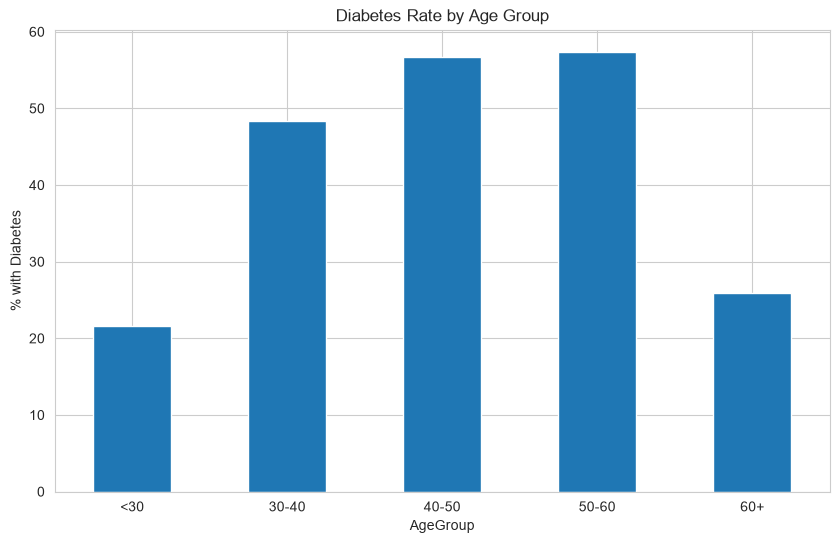

In [12]:
# Diabetes rate by age group

diabetes['AgeGroup'] = pd.cut(diabetes['Age'], bins=[0,30,40,50,60,100],
                              labels=['<30','30-40','40-50','50-60','60+'])

plt.figure(figsize=(10, 6))
diabetes.groupby('AgeGroup')['Outcome'].mean().mul(100).plot(kind='bar')
plt.ylabel('% with Diabetes')
plt.title('Diabetes Rate by Age Group')
plt.xticks(rotation=0)
plt.savefig('images/diabetes_by_age_group.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
diabetes['AgeGroup'].value_counts()

AgeGroup
<30      417
30-40    157
40-50    113
50-60     54
60+       27
Name: count, dtype: int64

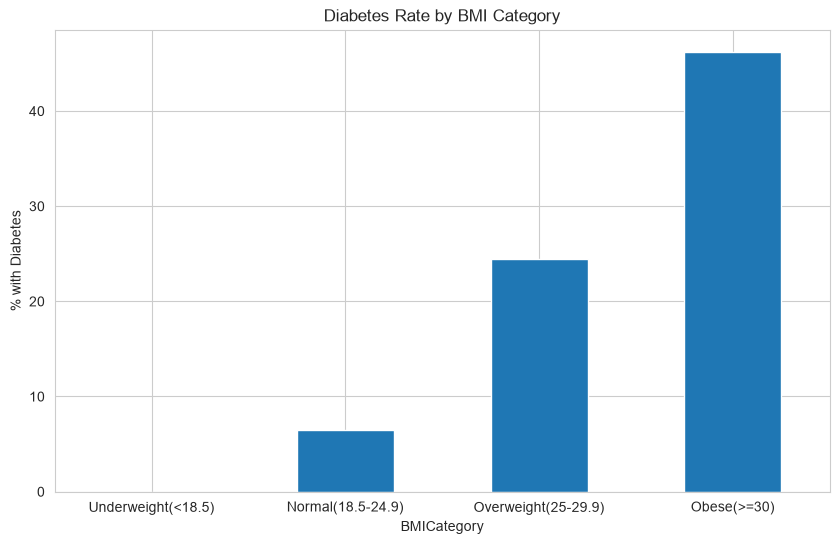

In [17]:
# Diabetes rate by BMI(Standard clinical cutoff)

diabetes['BMICategory'] = pd.cut(diabetes['BMI'], bins=[0, 18.5, 25, 30, 100],
                              labels=['Underweight(<18.5)','Normal(18.5-24.9)','Overweight(25-29.9)',
                              'Obese(>=30)'])

plt.figure(figsize=(10, 6))
diabetes.groupby('BMICategory')['Outcome'].mean().mul(100).plot(kind='bar')
plt.ylabel('% with Diabetes')
plt.title('Diabetes Rate by BMI Category')
plt.xticks(rotation=0)
plt.savefig('images/diabetes_by_bmi_category.png', dpi=300, bbox_inches='tight')
plt.show()

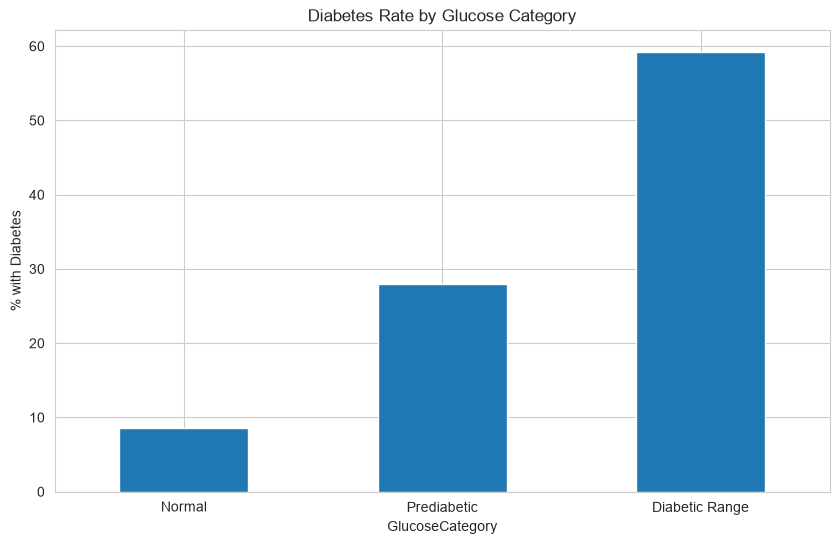

In [18]:
# Diabetes rate by Glucose categories (Standard Clinical Threshold)

diabetes['GlucoseCategory'] = pd.cut(diabetes['Glucose'], bins=[0, 100, 125, 300],
                              labels=['Normal','Prediabetic','Diabetic Range'])

plt.figure(figsize=(10, 6))
diabetes.groupby('GlucoseCategory')['Outcome'].mean().mul(100).plot(kind='bar')
plt.ylabel('% with Diabetes')
plt.title('Diabetes Rate by Glucose Category')
plt.xticks(rotation=0)
plt.savefig('images/diabetes_by_glucose_category.png', dpi=300, bbox_inches='tight')
plt.show()

Glucose category shows the strongest and most consistent risk gradient, with diabetes prevalence rising from ~9%(Normal) to ~59%(Diabetic Range). BMI category follows a similar clean upward trend, from ~6%(Normal) to `46%(Obese). Age group shows a rising trend up to the 50-60 bracket(~57%), but drops in the 60+ group(26%)-likely due to a small sample size in that bracket rather than a true reversal of risk, and should be interpreted cautiously. This group contains only 27 individuals-substantially fewer than the other age brackets. With such a small sample, the percentage is more sensitive to individual cases and may not reflect a true reversal of the age-related risk trend seen in the other groups.